# Random Forest

## Importación de Librerías

In [12]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

%matplotlib inline

## Variables de configuración

In [5]:
TIPO_DATASET = 1  # 1: Water Quality, 2: SRU2
ADD_FEATURES_TEMPORALES = True  # Agregar Features Temporales adicionales
ADD_FEATURES_LAG = False        # Agregar Features Lag adicionales

## Definición de rutas y directorios

In [ ]:
# Definir rutas
# Ruta Absoluta
current_dir = Path(os.getcwd())
# Raiz del proyecto
base_project_dir = current_dir.parent.parent.parent
data_dir = base_project_dir / "data"

# Se selecciona el dataset y la columna objetivo según la configuración
if TIPO_DATASET == 1:
    nombre_dataset = "water_quality"
    DATASET = data_dir / f"{nombre_dataset}.csv"
    TARGET_COLUMN = "Turbidity"
elif TIPO_DATASET == 2:
    nombre_dataset = "SRU2"
    DATASET = data_dir / f"{nombre_dataset}.csv"
    TARGET_COLUMN = "AI508"

print(f"Dataset seleccionado: {nombre_dataset}")
print(f"DATASET: {DATASET}")

# Se obtienen las columnas del archivo CSV para validación preliminar
df_temp = pd.read_csv(DATASET, nrows=0)
columnas = df_temp.columns.tolist()
print(f"Columnas detectadas: {columnas}")

# Se valida que la columna objetivo exista en el dataset
if TARGET_COLUMN not in columnas:
    raise ValueError(f"La columna '{TARGET_COLUMN}' no se encuentra en el dataset.")
print(f"La columna '{TARGET_COLUMN}' está presente en el dataset.")

# Se cargan los datos y se asegura el orden cronológico
df = pd.read_csv(DATASET, parse_dates=["Timestamp"], index_col="Timestamp")
is_equal = df.index.is_monotonic_increasing
print(f"¿Los datos están ordenados cronológicamente? {is_equal}")

if not is_equal:
    df = df.sort_index()
    print("Los datos han sido reordenados cronológicamente.")

Dataset seleccionado: water_quality
DATASET: c:\Users\samue\OneDrive\Documentos\UdeC\SoftSensors_methods\data\water_quality.csv
Columnas detectadas: ['Timestamp', 'ph', 'Temp', 'Cond', 'DO', 'Turbidity']
La columna 'Turbidity' está presente en el dataset.
¿Los datos están ordenados cronológicamente? True


## Feature Engineering

In [ ]:
# Se agregan Features temporales (Hora, Minuto y Día de la semana) si está configurado
if ADD_FEATURES_TEMPORALES:
    print("Se agregan Features temporales...")
    df.loc[:, 'hour'] = df.index.hour
    df.loc[:, 'day_of_week'] = df.index.dayofweek
    
# Se agrega el minuto siempre, según lógica original
df.loc[:, 'minute'] = df.index.minute

# Se agregan Lag Features en función de la TARGET_COLUMN (Lag de 1)
if ADD_FEATURES_LAG:
    print("Se agrega Lag feature...")
    df.loc[:, f'{TARGET_COLUMN}_lag1'] = df[TARGET_COLUMN].shift(1)
    
# Se eliminan filas con NaNs
print(f"Tamaño antes de eliminar NaNs: {len(df)}")
df = df.dropna()
print(f"Tamaño después de eliminar NaNs: {len(df)}")

Se agregan Features temporales...
Tamaño antes de eliminar NaNs: 14507
Tamaño después de eliminar NaNs: 14507


## Modelo

In [19]:
# Se divide el dataset en entrenamiento (70%) y prueba (30%)
print("Se divide el dataset en conjuntos de entrenamiento y prueba...")
print(f"Tamaño total del dataset: {len(df)}")

train_size = int(len(df) * 0.7)
df_train = df.iloc[:train_size]
df_test = df.iloc[train_size:]

# Se verifica que la división sea correcta y secuencial
if df_train.empty or df_test.empty:
    raise ValueError("Conjunto de entrenamiento o prueba vacío después de la división.")

if df_train.index.max() < df_test.index.min():
    print("La división entre entrenamiento y prueba se ha realizado correctamente (secuencial).")
else:
    raise ValueError("Error en la división entre entrenamiento y prueba.")

print(f"Tamaño del conjunto de entrenamiento: {len(df_train)}")
print(f"Tamaño del conjunto de prueba: {len(df_test)}")

# Se crea la lista de Features eliminando la columna objetivo y Timestamp
features = [col for col in df.columns if col not in [TARGET_COLUMN, 'Timestamp']]
print(f"Características seleccionadas para el modelo: {features}")

# Se separan los datos en X (features) e y (target)
X_train = df_train[features]
y_train = df_train[TARGET_COLUMN]
X_test = df_test[features]
y_test = df_test[TARGET_COLUMN]

# Se entrena el modelo Random Forest Regressor
print("Se entrena el modelo Random Forest Regressor...")
modelo = RandomForestRegressor(n_estimators=200, random_state=None, n_jobs=-1, verbose=0)
modelo.fit(X_train, y_train)
print("Modelo entrenado con éxito.")

Se divide el dataset en conjuntos de entrenamiento y prueba...
Tamaño total del dataset: 14507
La división entre entrenamiento y prueba se ha realizado correctamente (secuencial).
Tamaño del conjunto de entrenamiento: 10154
Tamaño del conjunto de prueba: 4353
Características seleccionadas para el modelo: ['ph', 'Temp', 'Cond', 'DO', 'hour', 'day_of_week', 'minute']
Se entrena el modelo Random Forest Regressor...
Modelo entrenado con éxito.


## Evaluación de Métricas

In [20]:
# Se evalúa el desempeño del modelo
print("Se evalúa el modelo...")
y_pred = modelo.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R2 Score: {r2}")
print(f"Mean Absolute Error (MAE): {mae}")

Se evalúa el modelo...
Root Mean Squared Error (RMSE): 0.0765605234130055
R2 Score: -0.04667726082609369
Mean Absolute Error (MAE): 0.052988976567884184


## Gráficos

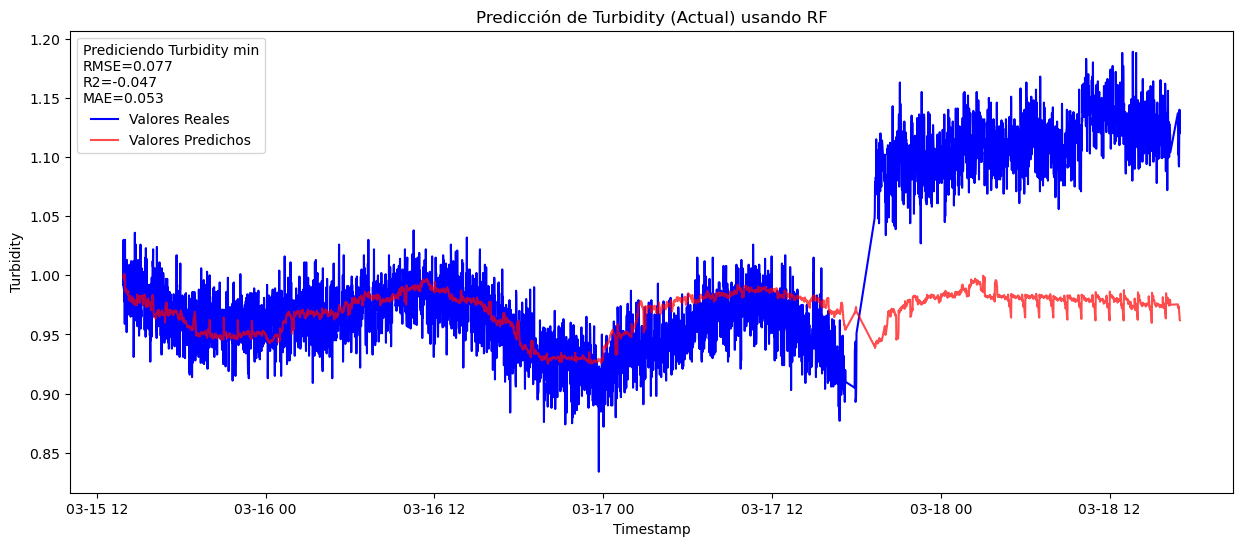

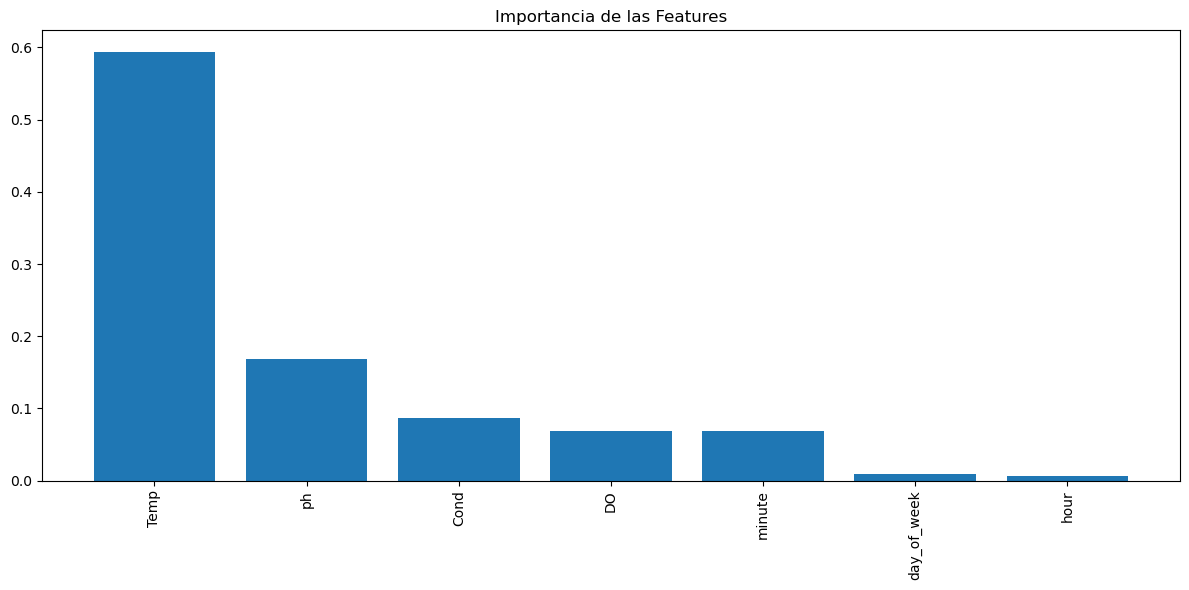

In [22]:
# Gráfico 1: Timestamp vs Valores Reales y Predichos
plt.figure(figsize=(15, 6))
plt.plot(df_test.index, y_test, label='Valores Reales', color='blue')
plt.plot(df_test.index, y_pred, label='Valores Predichos', color='red', alpha=0.7)
plt.xlabel('Timestamp')
plt.ylabel(TARGET_COLUMN)
    
titulo_prediccion = f'Predicción de {TARGET_COLUMN} (Actual) usando RF'

plt.title(titulo_prediccion)
plt.legend(title=f'Prediciendo {TARGET_COLUMN} min\nRMSE={rmse:.3f}\nR2={r2:.3f}\nMAE={mae:.3f}')

plt.show()

# Gráfico 2: Importancia de las Features
if hasattr(modelo, "feature_importances_"):
    importances = modelo.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    n_features = len(importances)
    positions = range(n_features)
    labels = [X_train.columns[i] for i in indices]
    
    plt.figure(figsize=(12, 6))
    plt.title("Importancia de las Features")
    plt.bar(positions, importances[indices], align="center")
    plt.xticks(positions, labels, rotation=90)
    plt.tight_layout()
        
    plt.show()
else:
    print("El modelo no proporciona 'feature_importances_' y no se puede mostrar la importancia de las features.")